In [1]:
import os
import numpy as np
from PIL import Image

data_dir = 'D:/pythonprojects/practice-github/20260615/train'      # 训练集根目录，包含 100 个类别的子文件夹
target_size = (32, 32)
class_names = sorted(os.listdir('D:/pythonprojects/practice-github/20260615/train'))   # 排序保证编号稳定
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
print(f'类别数量: {len(class_to_idx)}')      # 应为 100
all_class_matrices = []

for class_name, label in class_to_idx.items():
    class_path = os.path.join(data_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    images = []
    for fname in os.listdir(class_path):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            img_path = os.path.join(class_path, fname)
            # 统一为 RGB 并调整到 32×32（若已符合尺寸可省略 resize）
            img = Image.open(img_path).convert('RGB')
            if img.size != target_size:
                img = img.resize(target_size)
            # 转为 uint8 数组并展平为 3072 维
            img_array = np.array(img, dtype=np.uint8).reshape(-1)
            images.append(img_array)

    if not images:
        continue

    # 垂直堆叠为该类的矩阵 (n, 3072)
    class_matrix = np.stack(images, axis=0)

    # 添加标签列 (n, 1)，填充该类对应的编号
    label_col = np.full((class_matrix.shape[0], 1), label, dtype=np.uint8)
    class_matrix_with_label = np.concatenate([class_matrix, label_col], axis=1)  # (n, 3073)

    all_class_matrices.append(class_matrix_with_label)
    print(f'{class_name} (标签 {label}): {class_matrix.shape[0]} 张')

# 将所有类别的矩阵沿第一维拼接，得到完整数据集矩阵
data_matrix = np.concatenate(all_class_matrices, axis=0)
print(f'最终数据矩阵形状: {data_matrix.shape}')   # 例如 (6000, 3073)

类别数量: 100
apple (标签 0): 500 张
aquarium_fish (标签 1): 500 张
baby (标签 2): 500 张
bear (标签 3): 500 张
beaver (标签 4): 500 张
bed (标签 5): 500 张
bee (标签 6): 500 张
beetle (标签 7): 500 张
bicycle (标签 8): 500 张
bottle (标签 9): 500 张
bowl (标签 10): 500 张
boy (标签 11): 500 张
bridge (标签 12): 500 张
bus (标签 13): 500 张
butterfly (标签 14): 500 张
camel (标签 15): 500 张
can (标签 16): 500 张
castle (标签 17): 500 张
caterpillar (标签 18): 500 张
cattle (标签 19): 500 张
chair (标签 20): 500 张
chimpanzee (标签 21): 500 张
clock (标签 22): 500 张
cloud (标签 23): 500 张
cockroach (标签 24): 500 张
couch (标签 25): 500 张
crab (标签 26): 500 张
crocodile (标签 27): 500 张
cup (标签 28): 500 张
dinosaur (标签 29): 500 张
dolphin (标签 30): 500 张
elephant (标签 31): 500 张
flatfish (标签 32): 500 张
forest (标签 33): 500 张
fox (标签 34): 500 张
girl (标签 35): 500 张
hamster (标签 36): 500 张
house (标签 37): 500 张
kangaroo (标签 38): 500 张
keyboard (标签 39): 500 张
lamp (标签 40): 500 张
lawn_mower (标签 41): 500 张
leopard (标签 42): 500 张
lion (标签 43): 500 张
lizard (标签 44): 500 张
lobster (

In [3]:
import os
import numpy as np
from PIL import Image

# ---------- 请修改为你的真实数据集路径 ----------
# 方法①：使用正斜杠（跨平台通用）
data_dir = 'D:/pythonprojects/practice-github/20260615/train'   # 示例，请替换
# 方法②：使用原始字符串（保留 Windows 反斜杠）
# data_dir = r'C:\your_full_path\20260615\train'
# ------------------------------------------------

# 检查路径是否存在，避免 “系统找不到指定的路径”
if not os.path.exists(data_dir):
    raise FileNotFoundError(f"数据集路径不存在，请检查：{data_dir}")

# ---------- 1) 建立类别字典（0~99） ----------
class_names = sorted(os.listdir(data_dir))   # 按字母排序，保证编号稳定
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
print(f'检测到 {len(class_to_idx)} 个类别')

# ---------- 2) 按类别读取并存储为矩阵 ----------
target_size = (32, 32)
all_class_matrices = []

for class_name, label in class_to_idx.items():
    class_path = os.path.join(data_dir, class_name)
    if not os.path.isdir(class_path):   # 跳过非文件夹项
        continue

    images = []
    for fname in os.listdir(class_path):
        # 只处理常见图片格式
        if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            img_path = os.path.join(class_path, fname)
            # 统一转为 RGB 并调整尺寸为 32×32（若已知全部已为 32×32，可省略 resize）
            img = Image.open(img_path).convert('RGB')
            if img.size != target_size:
                img = img.resize(target_size)
            # 转换为 uint8 数组，并展平为一维 3072 向量
            img_array = np.array(img, dtype=np.uint8).reshape(-1)
            images.append(img_array)

    if not images:
        continue

    # 垂直堆叠为该类的样本矩阵，形状 (n, 3072)
    class_matrix = np.stack(images, axis=0)

    # 添加标签列 (n, 1)，全部填充该类对应的数字标签
    label_col = np.full((class_matrix.shape[0], 1), label, dtype=np.uint8)
    class_matrix_with_label = np.concatenate([class_matrix, label_col], axis=1)  # (n, 3073)

    all_class_matrices.append(class_matrix_with_label)
    print(f'{class_name} (标签 {label}): {class_matrix.shape[0]} 张图片')

# 合并所有类别为一个完整数据集矩阵 (总样本数, 3073)
data_matrix = np.concatenate(all_class_matrices, axis=0)
print(f'\n最终数据矩阵形状: {data_matrix.shape}')   # 例如 (6000, 3073)

检测到 100 个类别
apple (标签 0): 500 张图片
aquarium_fish (标签 1): 500 张图片
baby (标签 2): 500 张图片
bear (标签 3): 500 张图片
beaver (标签 4): 500 张图片
bed (标签 5): 500 张图片
bee (标签 6): 500 张图片
beetle (标签 7): 500 张图片
bicycle (标签 8): 500 张图片
bottle (标签 9): 500 张图片
bowl (标签 10): 500 张图片
boy (标签 11): 500 张图片
bridge (标签 12): 500 张图片
bus (标签 13): 500 张图片
butterfly (标签 14): 500 张图片
camel (标签 15): 500 张图片
can (标签 16): 500 张图片
castle (标签 17): 500 张图片
caterpillar (标签 18): 500 张图片
cattle (标签 19): 500 张图片
chair (标签 20): 500 张图片
chimpanzee (标签 21): 500 张图片
clock (标签 22): 500 张图片
cloud (标签 23): 500 张图片
cockroach (标签 24): 500 张图片
couch (标签 25): 500 张图片
crab (标签 26): 500 张图片
crocodile (标签 27): 500 张图片
cup (标签 28): 500 张图片
dinosaur (标签 29): 500 张图片
dolphin (标签 30): 500 张图片
elephant (标签 31): 500 张图片
flatfish (标签 32): 500 张图片
forest (标签 33): 500 张图片
fox (标签 34): 500 张图片
girl (标签 35): 500 张图片
hamster (标签 36): 500 张图片
house (标签 37): 500 张图片
kangaroo (标签 38): 500 张图片
keyboard (标签 39): 500 张图片
lamp (标签 40): 500 张图片
lawn_mower (标签 4

In [14]:
import cv2#导入cv库
import numpy as np#导入numpy
img = cv2.imread('D:/pythonprojects/practice-github/20260615/4.jpg')#读取图片
resized = cv2.resize(img, (600, 480))#指定尺寸
roi = img[50:300, 200:500]#切片截取
h, w = img.shape[:2]
M = cv2.getRotationMatrix2D((w/2, h/2), 10, 0.8)
rotated = cv2.warpAffine(img, M, (w, h))
cv2.imwrite('resized.jpg', resized)
cv2.imwrite('roi.jpg', roi)
cv2.imwrite('rotated.jpg', rotated)

True

In [15]:
import cv2
import numpy as np
img = cv2.imread('D:/pythonprojects/practice-github/20260615/4.jpg')
# alpha 控制对比度，beta 控制亮度
enhanced = cv2.convertScaleAbs(img, alpha=1.3, beta=20)
# 对灰度图做 CLAHE
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_img = clahe.apply(gray)
cv2.imwrite('enhanced.jpg', enhanced)
cv2.imwrite('clahe.png', clahe_img)

True

In [4]:
import cv2
import numpy as np
img = cv2.imread('4.jpg')
blur = cv2.GaussianBlur(img, (5, 5), 0)
median = cv2.medianBlur(img, 5)
# 锐化卷积核
kernel = np.array([[0, -1, 0],
 [-1, 5, -1],
 [0, -1, 0]])
sharp = cv2.filter2D(img, -1, kernel)
cv2.imwrite('gaussian_blur.jpg', blur)
cv2.imwrite('median.jpg', median)
cv2.imwrite('sharp.jpg', sharp)

True

In [1]:
import cv2
import numpy as np
gray = cv2.imread('4.jpg', cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
kernel = np.ones((5, 5), np.uint8)
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
cv2.imwrite('binary.png', binary)
cv2.imwrite('opened.png', opened)
cv2.imwrite('closed.png', closed)

True

In [4]:
import cv2
import os
import numpy as np

def process_and_crop_image(image_path, bbox, output_dir, save_name="cropped_region", save_format="png"):
    """
    读取图像，绘制边界框，裁剪指定区域并保存。
    
    参数:
    - image_path (str): 输入图像的路径
    - bbox (tuple/list): 边界框坐标，格式为 (x_min, y_min, x_max, y_max) 
                         即 (左上角X, 左上角Y, 右下角X, 右下角Y)
    - output_dir (str): 输出文件夹路径
    - save_name (str): 保存的文件名（不包含后缀）
    - save_format (str): 保存格式，'png' 或 'jpg'
    """
    
    # ================= 1. 读取图像 =================
    if not os.path.exists(image_path):
        print(f"❌ 错误: 找不到图像文件 '{image_path}'。将自动生成一张测试图。")
        # 生成一张 600x800 的随机彩色噪声图作为测试
        img = np.random.randint(0, 256, (600, 800, 3), dtype=np.uint8)
    else:
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError(f"无法解析图像，请检查文件是否损坏: {image_path}")

    # 获取图像的原始高度和宽度
    h, w = img.shape[:2]
    x_min, y_min, x_max, y_max = bbox

    # ================= 2. 边界安全检查 =================
    # 防止输入的坐标超出图像实际范围导致程序崩溃
    x_min = max(0, int(x_min))
    y_min = max(0, int(y_min))
    x_max = min(w, int(x_max))
    y_max = min(h, int(y_max))

    # 检查裁剪区域是否合法
    if x_min >= x_max or y_min >= y_max:
        raise ValueError(f"❌ 错误的边界框坐标: 裁剪区域宽度或高度小于等于0。")

    # ================= 3. 绘制边界框 =================
    # 注意：为了不影响后续裁剪出的纯净图像，我们在图像的【副本】上画框
    img_with_bbox = img.copy()
    
    # 绘制绿色矩形框 (BGR格式: 0,255,0)，线宽为 2
    cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
    
    # 可选：在框的左上角添加文字标签
    label = "Target"
    cv2.putText(img_with_bbox, label, (x_min, y_min - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # 显示带框的图像 (按任意键关闭)
    cv2.imshow("Image with Bounding Box", img_with_bbox)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    # ================= 4. 裁剪图像 (核心) =================
    # NumPy 数组切片：img[y_start:y_end, x_start:x_end]
    # 注意：第一个维度是 Y(行)，第二个维度是 X(列)
    cropped_img = img[y_min:y_max, x_min:x_max]

    # ================= 5. 保存到指定文件夹 =================
    # 如果输出文件夹不存在，则自动创建 (支持多级目录创建)
    os.makedirs(output_dir, exist_ok=True)

    # 规范化保存格式
    save_format = save_format.lower().replace('.', '')
    if save_format not in ['png', 'jpg', 'jpeg']:
        print("⚠️ 警告: 不支持的格式，已自动回退为 'png'")
        save_format = 'png'

    # 拼接完整的输出路径
    output_filename = f"{save_name}.{save_format}"
    output_path = os.path.join(output_dir, output_filename)

    # 写入磁盘
    success = cv2.imwrite(output_path, cropped_img)
    
    if success:
        print(f"✅ 成功! 裁剪后的图像已保存至: {output_path}")
        print(f"📏 裁剪尺寸: {cropped_img.shape[1]}x{cropped_img.shape[0]} (宽x高)")
    else:
        print(f"❌ 失败! 无法写入文件，请检查路径权限: {output_path}")


# ================= 测试运行 =================
if __name__ == "__main__":
    # 配置参数
    INPUT_IMAGE = "4.jpg"          # 替换为你的图片路径
    BOUNDING_BOX = (150, 100, 450, 400)   # (x_min, y_min, x_max, y_max)
    OUTPUT_FOLDER = "./output_crops"      # 输出文件夹
    FILE_NAME = "face_crop_01"            # 文件名
    FORMAT = "png"                        # 保存格式 ('png' 或 'jpg')

    process_and_crop_image(
        image_path=INPUT_IMAGE,
        bbox=BOUNDING_BOX,
        output_dir=OUTPUT_FOLDER,
        save_name=FILE_NAME,
        save_format=FORMAT
    )

✅ 成功! 裁剪后的图像已保存至: ./output_crops\face_crop_01.png
📏 裁剪尺寸: 300x300 (宽x高)


In [10]:
import cv2

# 正常读取 3 通道彩色图
img_color = cv2.imread('4.jpg', cv2.IMREAD_COLOR)

# OpenCV 默认通道顺序是 B, G, R (索引 0, 1, 2)
b_channel = img_color[:, :, 0]  # 提取纯蓝通道 (单通道 2D 数组)
g_channel = img_color[:, :, 1]  # 提取纯绿通道
r_channel = img_color[:, :, 2]  # 提取纯红通道

# 保存提取出的单通道 (保存出来的图片看起来也是灰度的，因为单通道只表示亮度)
cv2.imwrite('red_channel_only.png', r_channel)

True

In [13]:
import cv2
import numpy as np
import os
import time

class ImageCropper:
    def __init__(self, image_path, output_dir="cropped_images"):
        """
        初始化图像裁剪器
        :param image_path: 输入图像路径
        :param output_dir: 裁剪结果保存目录
        """
        # 1. 读取图像
        self.image_path = image_path
        self.original_img = cv2.imread(image_path)
        if self.original_img is None:
            raise ValueError(f"❌ 无法加载图像: {image_path}")
        
        # 2. 创建输出目录
        self.output_dir = output_dir
        os.makedirs(self.output_dir, exist_ok=True)
        
        # 3. 初始化状态变量
        self.drawing = False
        self.start_point = (-1, -1)
        self.current_rect = None
        self.cropped_count = 0
        self.all_rects = []  # 存储所有已完成的裁剪框
        
        # 4. 创建窗口和鼠标回调
        self.window_name = "Image Cropper - Click & Drag to Crop (ESC to Quit)"
        cv2.namedWindow(self.window_name)
        cv2.setMouseCallback(self.window_name, self.mouse_callback)
        
        # 5. 显示初始图像
        self.display_img = self.original_img.copy()
        self.update_display()
        
        print("📌 使用指南:")
        print("   • 按住鼠标左键拖动绘制裁剪区域")
        print("   • 松开鼠标自动裁剪并保存")
        print("   • 按 ESC 键退出程序")
        print("   • 按 R 键重置所有裁剪框")
        print(f"📁 裁剪结果将保存到: {os.path.abspath(self.output_dir)}")

    def mouse_callback(self, event, x, y, flags, param):
        """鼠标事件处理函数"""
        if event == cv2.EVENT_LBUTTONDOWN:
            # 记录起始点
            self.drawing = True
            self.start_point = (x, y)
            self.current_rect = None
        
        elif event == cv2.EVENT_MOUSEMOVE:
            # 实时更新矩形框
            if self.drawing:
                self.current_rect = (self.start_point[0], self.start_point[1], x, y)
                self.update_display()
        
        elif event == cv2.EVENT_LBUTTONUP:
            # 完成裁剪区域
            self.drawing = False
            self.current_rect = (self.start_point[0], self.start_point[1], x, y)
            
            # 保存裁剪结果
            if self.current_rect:
                self.save_cropped_region()
                self.all_rects.append(self.current_rect)
                self.current_rect = None
                self.update_display()

    def update_display(self):
        """更新显示图像（添加临时矩形和已完成矩形）"""
        self.display_img = self.original_img.copy()
        
        # 绘制所有已完成的裁剪框（半透明）
        for i, rect in enumerate(self.all_rects):
            x1, y1, x2, y2 = rect
            # 用不同颜色区分
            color = (0, 255, 0) if i % 2 == 0 else (255, 0, 0)
            overlay = self.display_img.copy()
            cv2.rectangle(overlay, (x1, y1), (x2, y2), color, 2)
            cv2.addWeighted(overlay, 0.7, self.display_img, 0.3, 0, self.display_img)
        
        # 绘制当前正在绘制的矩形（绿色）
        if self.current_rect:
            x1, y1, x2, y2 = self.current_rect
            cv2.rectangle(self.display_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
        # 显示状态信息
        status_text = f"已裁剪: {len(self.all_rects)} 个区域 | 按 R 重置"
        cv2.putText(self.display_img, status_text, (10, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
        
        # 显示图像
        cv2.imshow(self.window_name, self.display_img)

    def save_cropped_region(self):
        """裁剪并保存当前区域"""
        x1, y1, x2, y2 = self.current_rect
        # 确保坐标顺序正确
        x_min, x_max = min(x1, x2), max(x1, x2)
        y_min, y_max = min(y1, y2), max(y1, y2)
        
        # 检查有效区域
        if x_max - x_min < 10 or y_max - y_min < 10:
            print("⚠️ 裁剪区域太小，跳过保存")
            return
        
        # 裁剪图像
        cropped_img = self.original_img[y_min:y_max, x_min:x_max]
        
        # 生成唯一文件名
        timestamp = int(time.time())
        self.cropped_count += 1
        filename = f"crop_{self.cropped_count:03d}_{timestamp}.png"
        output_path = os.path.join(self.output_dir, filename)
        
        # 保存图像
        cv2.imwrite(output_path, cropped_img)
        print(f"✅ 已保存裁剪区域: {filename} | 尺寸: {cropped_img.shape[1]}x{cropped_img.shape[0]}")
        print(f"   保存路径: {os.path.abspath(output_path)}")

    def run(self):
        """运行主循环"""
        while True:
            key = cv2.waitKey(1) & 0xFF
            
            # 退出程序
            if key == 27:  # ESC
                print("\n🎉 程序已退出")
                print(f"📁 总裁剪数量: {len(self.all_rects)}")
                print(f"📁 裁剪结果目录: {os.path.abspath(self.output_dir)}")
                break
                
            # 重置所有裁剪框
            elif key == ord('r'):
                self.all_rects = []
                self.cropped_count = 0
                self.update_display()
                print("🔄 已重置所有裁剪框")

# ================= 执行程序 =================
if __name__ == "__main__":
    # 配置参数
    INPUT_IMAGE = "4.jpg"  # 替换为你的图片路径
    OUTPUT_FOLDER = "cropped_images"  # 自定义输出文件夹
    
    # 检查输入文件是否存在
    if not os.path.exists(INPUT_IMAGE):
        print(f"⚠️ 警告: 未找到输入图像 '{INPUT_IMAGE}'，将使用测试图像")
        # 创建测试图像
        test_img = np.ones((600, 800, 3), dtype=np.uint8) * 200
        cv2.putText(test_img, "TEST IMAGE", (200, 300), 
                   cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 5)
        cv2.imwrite(INPUT_IMAGE, test_img)
    
    # 创建并运行裁剪器
    cropper = ImageCropper(INPUT_IMAGE, OUTPUT_FOLDER)
    cropper.run()
    
    # 关闭所有窗口
    cv2.destroyAllWindows()

📌 使用指南:
   • 按住鼠标左键拖动绘制裁剪区域
   • 松开鼠标自动裁剪并保存
   • 按 ESC 键退出程序
   • 按 R 键重置所有裁剪框
📁 裁剪结果将保存到: d:\pythonprojects\practice-github\20260615\cropped_images
✅ 已保存裁剪区域: crop_001_1781505956.png | 尺寸: 63x102
   保存路径: d:\pythonprojects\practice-github\20260615\cropped_images\crop_001_1781505956.png
✅ 已保存裁剪区域: crop_002_1781505959.png | 尺寸: 143x122
   保存路径: d:\pythonprojects\practice-github\20260615\cropped_images\crop_002_1781505959.png
✅ 已保存裁剪区域: crop_003_1781505963.png | 尺寸: 143x122
   保存路径: d:\pythonprojects\practice-github\20260615\cropped_images\crop_003_1781505963.png
✅ 已保存裁剪区域: crop_004_1781505964.png | 尺寸: 82x90
   保存路径: d:\pythonprojects\practice-github\20260615\cropped_images\crop_004_1781505964.png


KeyboardInterrupt: 

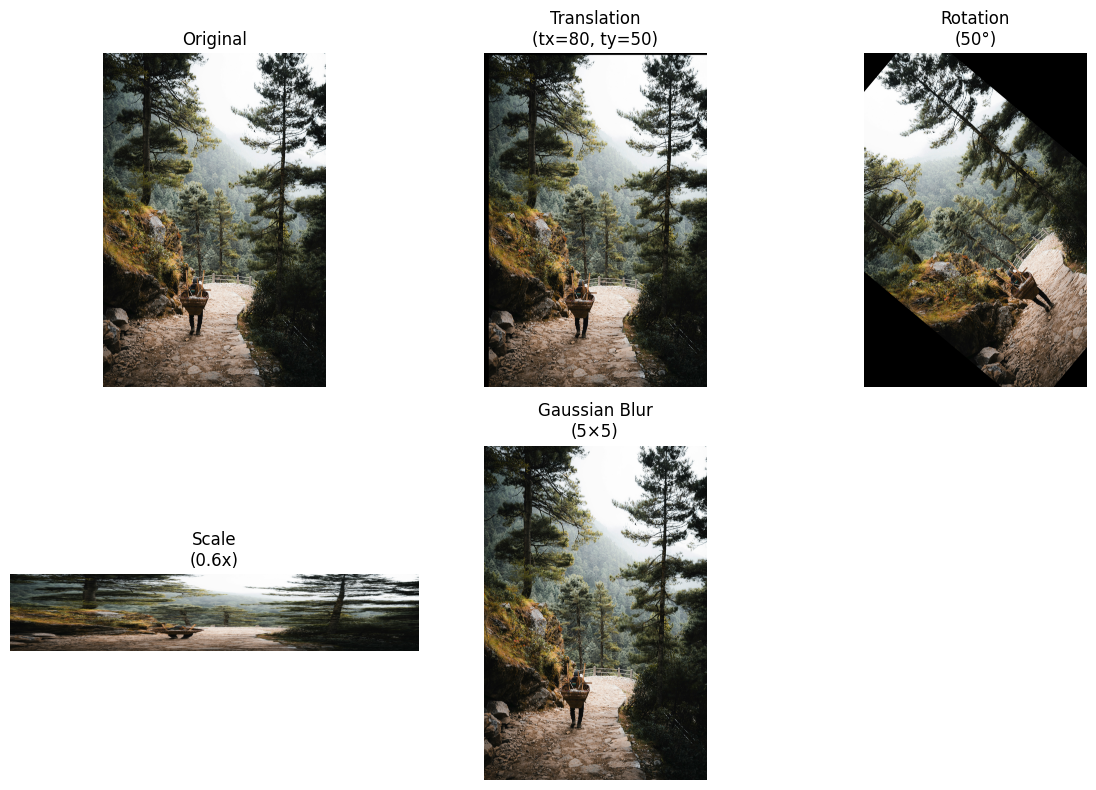

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1. 读取图像 ----------
img_bgr = cv2.imread('4.jpg')          # 请确保图像存在
if img_bgr is None:
    raise FileNotFoundError("图像不存在：'input.jpg'")
# 获取图像尺寸
h, w = img_bgr.shape[:2]

# ---------- 2. 定义各种变换 ----------
# 2.1 平移（向右50，向下30像素）
tx, ty = 80, 50
M_trans = np.float32([[1, 0, tx],
                      [0, 1, ty]])
translated = cv2.warpAffine(img_bgr, M_trans, (w, h))

# 2.2 旋转（绕图像中心旋转30度，缩放因子1.0）
center = (w // 2, h // 2)
angle = 50
scale = 1.0
M_rot = cv2.getRotationMatrix2D(center, angle, scale)
rotated = cv2.warpAffine(img_bgr, M_rot, (w, h))

# 2.3 缩放（将图像尺寸变为原来的0.6倍，即缩小）
new_w, new_h = int(w * 0.8), int(h * 0.1)
scaled = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

# 2.4 高斯模糊（5x5核，标准差由核尺寸自动计算）
blurred = cv2.GaussianBlur(img_bgr, (5, 5), 0)

# ---------- 3. 转换为RGB以便matplotlib正确显示 ----------
def bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_rgb = bgr_to_rgb(img_bgr)
translated_rgb = bgr_to_rgb(translated)
rotated_rgb = bgr_to_rgb(rotated)
scaled_rgb = bgr_to_rgb(scaled)        # 注意缩放后尺寸不同
blurred_rgb = bgr_to_rgb(blurred)

# ---------- 4. 可视化（子图对比） ----------
plt.figure(figsize=(12, 8))

# 原图
plt.subplot(2, 3, 1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

# 平移
plt.subplot(2, 3, 2)
plt.imshow(translated_rgb)
plt.title(f'Translation\n(tx={tx}, ty={ty})')
plt.axis('off')

# 旋转
plt.subplot(2, 3, 3)
plt.imshow(rotated_rgb)
plt.title(f'Rotation\n({angle}°)')
plt.axis('off')

# 缩放（放在新行）
plt.subplot(2, 3, 4)
plt.imshow(scaled_rgb)
plt.title(f'Scale\n(0.6x)')
plt.axis('off')

# 高斯模糊
plt.subplot(2, 3, 5)
plt.imshow(blurred_rgb)
plt.title('Gaussian Blur\n(5×5)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
import cv2
import numpy as np

# 创建黑色背景或读取图片
#img = np.zeros((400, 600, 3), dtype=np.uint8) + 255  # 白色背景
# 若用真实图片：
img = cv2.imread('4.jpg')

# 1. 普通矩形
cv2.rectangle(img, (50, 50), (200, 150), (0, 255, 0), 2)

# 2. 旋转矩形
cx, cy = 500, 500
box = cv2.boxPoints(((cx, cy), (120, 60), 20))
box = np.int32(box)
cv2.polylines(img, [box], True, (0, 0, 255), 2)

# 3. 圆形框
cv2.circle(img, (120, 250), 60, (255, 0, 0), 2)

# 4. 多边形框
pts = np.array([[300,200],[450,180],[480,300],[320,350]], dtype=np.int32)
cv2.polylines(img, [pts], True, (255, 0, 255), 2)

# 5. 带标签的矩形（放在右下角）
x1, y1, x2, y2 = 400, 300, 560, 360
cv2.rectangle(img, (x1, y1), (x2, y2), (255, 255, 0), 2)
label = "person 0.85"
cv2.rectangle(img, (x1, y1-20), (x2, y1), (255,255,0), -1)  # 填充背景
cv2.putText(img, label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 
            0.5, (0,0,0), 1)

# 显示与保存
cv2.imshow('Various Bounding Boxes', img)
cv2.waitKey(0)
cv2.destroyAllWindows()
# cv2.imwrite('bboxes.jpg', img)

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm # 用于显示进度条 (可选: pip install tqdm)

def load_dataset_as_matrix(data_dir, target_size=(32, 32)):
    """
    按类别读取图像数据集，并转换为 NumPy 矩阵形式。
    
    :param data_dir: 数据集根目录路径（包含各个类别的子文件夹）
    :param target_size: 目标图像尺寸 (宽, 高)，默认 (32, 32)
    :return: 
        - images_matrix: 形状为 (N, 32, 32, 3) 的 uint8 NumPy 数组
        - labels_matrix: 形状为 (N,) 的 int32 NumPy 数组
        - class_names: 类别名称列表（索引对应 labels_matrix 中的数字）
    """
    images_list = []
    labels_list = []
    
    # 1. 获取所有类别文件夹，并按字母顺序排序（确保标签映射一致性）
    class_names = sorted([d for d in os.listdir(data_dir) 
                          if os.path.isdir(os.path.join(data_dir, d))])
    
    # 创建 类别名称 -> 整数标签 的映射字典 (例如: {'bird': 0, 'cat': 1, 'dog': 2})
    class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
    
    print(f"🔍 发现 {len(class_names)} 个类别: {class_names}")
    print(f"📐 目标图像尺寸: {target_size[0]}x{target_size[1]}x3 (RGB)")
    print("-" * 50)
    
    # 2. 遍历每个类别文件夹
    for class_name in class_names:
        class_dir = os.path.join(data_dir, class_name)
        class_label = class_to_idx[class_name]
        
        # 获取该类别下的所有图像文件
        file_names = [f for f in os.listdir(class_dir) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
        
        print(f"📂 正在处理类别 [{class_name}] (标签: {class_label})，共 {len(file_names)} 张图像...")
        
        # 3. 遍历并读取每张图像
        for file_name in tqdm(file_names, desc=f"  -> {class_name}", leave=False):
            file_path = os.path.join(class_dir, file_name)
            
            try:
                # 读取图像 (OpenCV 默认读取为 BGR 格式)
                img_bgr = cv2.imread(file_path)
                
                if img_bgr is None:
                    print(f"⚠️ 警告: 无法读取图像，跳过: {file_path}")
                    continue
                
                # 转换颜色空间：BGR -> RGB (深度学习模型标准输入格式)
                img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                
                # 调整图像尺寸至 32x32
                img_resized = cv2.resize(img_rgb, target_size, interpolation=cv2.INTER_AREA)
                
                # 将处理好的图像和标签加入列表
                images_list.append(img_resized)
                labels_list.append(class_label)
                
            except Exception as e:
                print(f"❌ 处理图像 {file_path} 时出错: {e}")
                
    # 4. 将列表转换为 NumPy 矩阵
    if not images_list:
        raise ValueError("未能成功加载任何图像，请检查数据目录和图像格式。")
        
    print("-" * 50)
    print("⚙️ 正在将数据转换为 NumPy 矩阵...")
    
    # 转换为矩阵并指定数据类型以优化内存
    images_matrix = np.array(images_list, dtype=np.uint8) 
    labels_matrix = np.array(labels_list, dtype=np.int32)
    
    print(f"✅ 数据集加载完成！")
    print(f"   - 图像矩阵形状 (Images Shape): {images_matrix.shape}")
    print(f"   - 标签矩阵形状 (Labels Shape): {labels_matrix.shape}")
    print(f"   - 图像数据类型: {images_matrix.dtype}")
    
    return images_matrix, labels_matrix, class_names

# ================= 使用示例 =================
if __name__ == "__main__":
    # 替换为您的实际数据集路径
    DATASET_PATH = "train"  
    
    # 如果目录不存在，创建一个虚拟目录用于测试
    if not os.path.exists(DATASET_PATH):
        print(f"⚠️ 目录 {DATASET_PATH} 不存在，正在生成测试数据...")
        os.makedirs(f"{DATASET_PATH}/class_A", exist_ok=True)
        os.makedirs(f"{DATASET_PATH}/class_B", exist_ok=True)
        # 生成几张 64x64 的随机彩色测试图
        for i in range(5):
            cv2.imwrite(f"{DATASET_PATH}/class_A/img_{i}.jpg", np.random.randint(0, 255, (64, 64, 3), dtype=np.uint8))
            cv2.imwrite(f"{DATASET_PATH}/class_B/img_{i}.jpg", np.random.randint(0, 255, (100, 100, 3), dtype=np.uint8))

    # 执行加载
    X_train, y_train, classes = load_dataset_as_matrix(DATASET_PATH, target_size=(32, 32))
    
    # 验证单张图像
    print(f"\n🖼️ 第一张图像的数据维度: {X_train[0].shape}")
    print(f"🏷️ 第一张图像的标签: {y_train[0]} (对应类别: {classes[y_train[0]]})")

🔍 发现 100 个类别: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 

📂 正在处理类别 [aquarium_fish] (标签: 1)，共 500 张图像...


📂 正在处理类别 [baby] (标签: 2)，共 500 张图像...


📂 正在处理类别 [bear] (标签: 3)，共 500 张图像...


📂 正在处理类别 [beaver] (标签: 4)，共 500 张图像...


...

📂 正在处理类别 [willow_tree] (标签: 96)，共 500 张图像...


📂 正在处理类别 [wolf] (标签: 97)，共 500 张图像...


📂 正在处理类别 [woman] (标签: 98)，共 500 张图像...


📂 正在处理类别 [worm] (标签: 99)，共 500 张图像...


--------------------------------------------------
⚙️ 正在将数据转换为 NumPy 矩阵...
✅ 数据集加载完成！
   - 图像矩阵形状 (Images Shape): (50000, 32, 32, 3)
   - 标签矩阵形状 (Labels Shape): (50000,)
   - 图像数据类型: uint8

🖼️ 第一张图像的数据维度: (32, 32, 3)
🏷️ 第一张图像的标签: 0 (对应类别: apple)


In [5]:
import os 
import cv2
import numpy as np
from tqdm import tqdm
def load_dataset_as_matrix(data_dir,target_size=(32,32)):
    images_list = []
    labels_list = []
    class_names = sorted([d for d in os.listdir(data_dir)
                          if os.path.isdir(os.path.join(data_dir,d))])
    class_to_idx = {class_name:idx for idx,class_name in enumerate(class_names)}
    print(f"🔍 发现 {len(class_names)} 个类别: {class_names}")
    print(f"📐 目标图像尺寸: {target_size[0]}x{target_size[1]}x3 (RGB)")
    print("-" * 50)
    for class_name in class_names:
        class_dir = os.path.join(data_dir,class_name)
        class_label = class_to_idx[class_name]
        file_names = [f for f in os.listdir(class_dir)
                      if f.lower().endwith(('.png','.jpg','.jpeg','.bmp'))]
        print(f"📂 正在处理类别 [{class_name}] (标签: {class_label})，共 {len(file_names)} 张图像...")
        for file_name in tqdm(file_names,desc=f"  -> {class_name}",leave=False):
            file_path = os.path.join(class_dir,file_name)
            try:
                img_bgr = cv2.imread(file_path)
                if img_bgr is None:
                    print(f"⚠️ 警告: 无法读取图像，跳过: {file_path}")
                    continue
                img_rgb = cv2.cvtColor(img_bgr,cv2.COLOR_BGR2RGB)
                img_resized = cv2.resize(img_rgb,target_size,interpolation=cv2.INTER_AREA)
                images_list.append(img_resized)
                labels_list.append(class_label)
            except Exception as e:
                print(f"❌ 处理图像 {file_path} 时出错: {e}")
        if not images_list:
            raise ValueError("未能成功加载任何图像，请检查数据目录和图像格式。")
        print("-" * 50)
        print("⚙️ 正在将数据转换为 NumPy 矩阵...")
        images_matrix = np.array(images_list,dtype=np.uint8)
        labels_matrix = np.array(labels_list,dtype=np.int32)
        print(f"✅ 数据集加载完成！")
        print(f"   - 图像矩阵形状 (Images Shape): {images_matrix.shape}")
        print(f"   - 标签矩阵形状 (Labels Shape): {labels_matrix.shape}")
        print(f"   - 图像数据类型: {images_matrix.dtype}")
if __name__ =="__main__":
    DATASET_PATH = "20260615/4.jpg"
    if not os.path.exists(DATASET_PATH):
        print(f"⚠️ 目录 {DATASET_PATH} 不存在，正在生成测试数据...")
        os.makedirs(f"{DATASET_PATH}/class_A", exist_ok=True)
        os.makedirs(f"{DATASET_PATH}/class_B", exist_ok=True)
        for i in range(5):
            cv2.imwrite(f"{DATASET_PATH}/class_A/img_{i}.jpg",np.random.randint(0, 255, (64, 64, 3), dtype=np.uint8))
            cv2.imwrite(f"{DATASET_PATH}/class_B/img_{i}.jpg", np.random.randint(0, 255, (100, 100, 3), dtype=np.uint8))
    X_train, y_train, classes = load_dataset_as_matrix(DATASET_PATH, target_size=(32, 32))
    print(f"\n🖼️ 第一张图像的数据维度: {X_train[0].shape}")
    print(f"🏷️ 第一张图像的标签: {y_train[0]} (对应类别: {classes[y_train[0]]})")

🔍 发现 2 个类别: ['class_A', 'class_B']
📐 目标图像尺寸: 32x32x3 (RGB)
--------------------------------------------------


AttributeError: 'str' object has no attribute 'endwith'

In [3]:
print(1)

1


In [1]:
import os
import numpy as np
from PIL import Image

def load_data_flat(data_dir):
    """返回 (总样本数, 3073) 的矩阵，最后一列是标签"""
    class_names = sorted(os.listdir(data_dir))
    class_to_idx = {name: i for i, name in enumerate(class_names)}
    
    all_data = []
    for class_name, idx in class_to_idx.items():
        folder = os.path.join(data_dir, class_name)
        rows = []
        for fname in os.listdir(folder):
            if not fname.lower().endswith(('.png','.jpg','.jpeg','.bmp')):
                continue
            img = Image.open(os.path.join(folder, fname)).convert('RGB')
            if img.size != (32, 32):
                img = img.resize((32, 32))
            vec = np.array(img, dtype=np.uint8).reshape(-1)   # 3072
            rows.append(vec)
        if rows:
            mat = np.array(rows)                              # (n, 3072)
            label_col = np.full((mat.shape[0], 1), idx, dtype=np.uint8)
            all_data.append(np.concatenate([mat, label_col], axis=1))
    
    data = np.concatenate(all_data, axis=0)                  # (N, 3073)
    np.random.shuffle(data)                                  # 打乱
    return data

# 使用
data = load_data_flat('train')
print(data.shape)  # (N, 3073)

(50000, 3073)


共找到 5949 张数字 9 的图像。


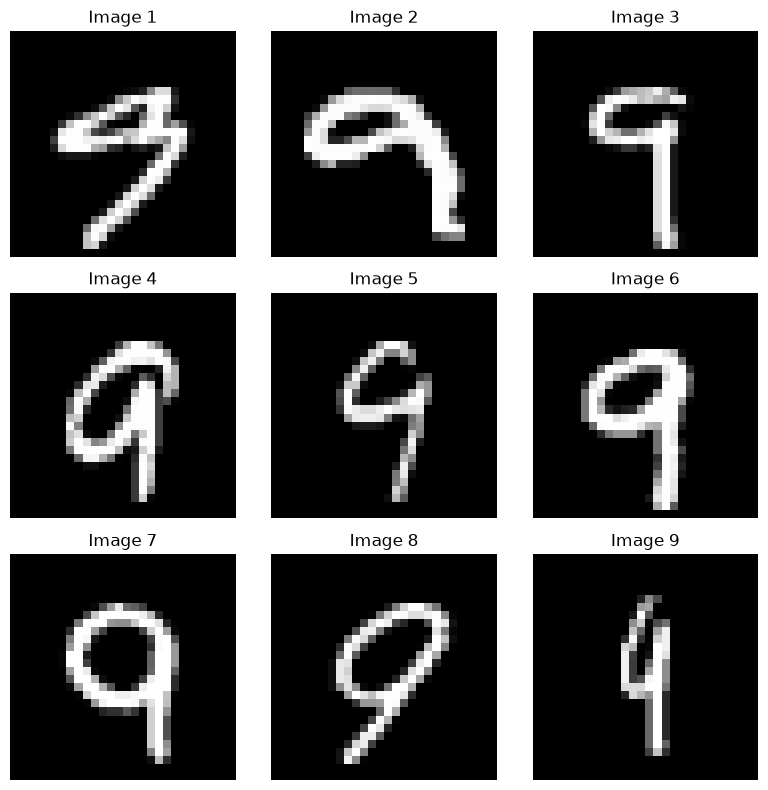

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 加载 MNIST 数据集
# 请替换为您的实际文件路径
file_path = 'mnist.npz' 
with np.load(file_path) as data:
    train_images = data['x_train']
    train_labels = data['y_train']

# 2. 筛选出所有标签为 9 的图像
# train_labels 是一维数组，值为 0-9
nine_indices = np.where(train_labels == 9)[0]
nine_images = train_images[nine_indices]

print(f"共找到 {len(nine_images)} 张数字 9 的图像。")

# 3. 随机选择 9 张图像用于展示
num_samples = 9
selected_indices = np.random.choice(len(nine_images), num_samples, replace=False)
selected_nine_images = nine_images[selected_indices]

# 4. 使用 Matplotlib 绘制 3x3 网格
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    # 从 [28, 28] 的灰度图像中移除通道维度
    img = selected_nine_images[i]
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Image {i+1}')
    ax.axis('off')  # 关闭坐标轴

plt.tight_layout()
plt.show()

In [1]:
import numpy as np

# 1. 加载 MNIST 数据集
file_path = 'mnist.npz' 
with np.load(file_path) as data:
    train_images = data['x_train']  # 形状: (60000, 28, 28)
    train_labels = data['y_train']  # 形状: (60000,)

# 2. 筛选出所有标签为 4 的图像
four_indices = np.where(train_labels == 4)[0]
four_images = train_images[four_indices]  # 形状: (N, 28, 28)，N 约为 5800

print(f"共找到 {len(four_images)} 张数字 4 的图像。")

# 3. (可选) 为了演示，我们只取前 2000 张
# 在实际应用中，您可以使用所有可用的样本
num_samples = 2000
four_images_subset = four_images[:num_samples]

# 4. 将每张 28x28 的图像展平为一个 784 维的向量
# -1 表示自动计算该维度的大小，以保持总元素数量不变
flattened_images = four_images_subset.reshape(num_samples, -1)

print(f"展平后的特征矩阵形状: {flattened_images.shape}")
# 输出: 展平后的特征矩阵形状: (2000, 784)

# 现在，flattened_images 就是您所说的 2000x784 的矩阵
# 每一行代表一张数字 4 的图像的所有像素值

共找到 5842 张数字 4 的图像。
展平后的特征矩阵形状: (2000, 784)


共找到 5842 张数字 4 的图像。
共找到 6265 张数字 7 的图像。


C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_24864\1761286415.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


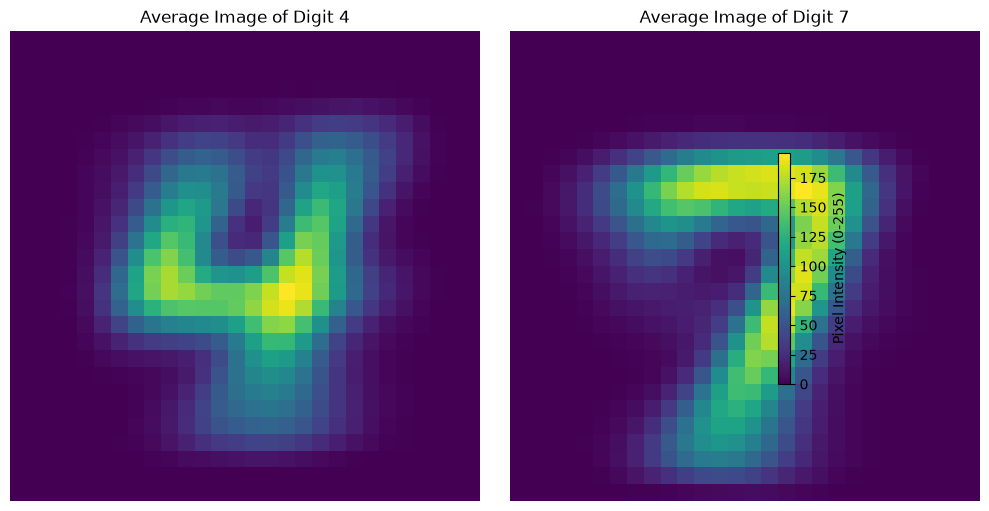

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 加载 MNIST 数据集
file_path = 'mnist.npz' 
with np.load(file_path) as data:
    train_images = data['x_train']
    train_labels = data['y_train']

# 2. 筛选出所有标签为 4 的图像
four_indices = np.where(train_labels == 4)[0]
four_images = train_images[four_indices]  # 形状: (N, 28, 28)

# 3. 筛选出所有标签为 7 的图像
seven_indices = np.where(train_labels == 7)[0]
seven_images = train_images[seven_indices]  # 形状: (M, 28, 28)

print(f"共找到 {len(four_images)} 张数字 4 的图像。")
print(f"共找到 {len(seven_images)} 张数字 7 的图像。")

# 4. 计算每个数字的平均图像
# 这会将多张图像叠加，显示出该数字的“典型”形状
# 首先将图像数据类型转换为 float32 以便进行平均计算
four_images_avg = np.mean(four_images.astype('float32'), axis=0)
seven_images_avg = np.mean(seven_images.astype('float32'), axis=0)

# 5. 使用 Matplotlib 绘制 1x2 网格
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 第一个子图：数字 4 的平均热力图
# cmap='viridis' 是一个常用的热力图颜色映射，也可以换成 'hot', 'plasma' 等
im0 = axes[0].imshow(four_images_avg, cmap='viridis')
axes[0].set_title('Average Image of Digit 4')
axes[0].axis('off')

# 第二个子图：数字 7 的平均热力图
im1 = axes[1].imshow(seven_images_avg, cmap='viridis')
axes[1].set_title('Average Image of Digit 7')
axes[1].axis('off')

# 6. 添加一个共享的颜色条
# 这样可以直观地比较两个图的像素强度差异
fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.6, label='Pixel Intensity (0-255)')

plt.tight_layout()
plt.show()


共找到 6265 张数字 7 的图像。
共找到 5842 张数字 4 的图像。


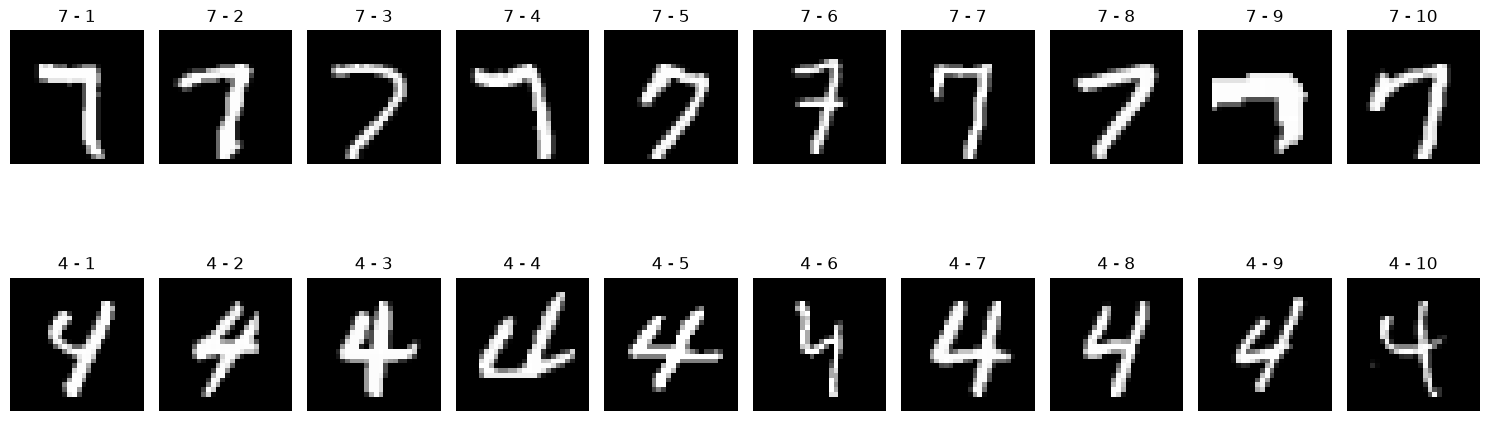

In [3]:
import numpy as np
import matplotlib.pyplot as plt
file_path = 'mnist.npz'
with np.load(file_path) as data:
    train_images = data['x_train']
    train_labels = data['y_train']
four_indices = np.where(train_labels == 4)[0]
four_images = train_images[four_indices]
seven_indices = np.where(train_labels == 7)[0]
seven_images = train_images[seven_indices]
print(f"共找到 {len(seven_images)} 张数字 7 的图像。")
print(f"共找到 {len(four_images)} 张数字 4 的图像。")
num_samples = 10
selected_seven_indices = np.random.choice(len(seven_images),num_samples,replace=False)
selected_seven_images = seven_images[selected_seven_indices]
selected_four_indices = np.random.choice(len(four_images),num_samples,replace=False)
selected_four_images = four_images[selected_four_indices]
fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))
for i in range(num_samples):
    axes[0, i].imshow(selected_seven_images[i],cmap='gray')
    axes[0, i].set_title(f'7 - {i+1}')
    axes[0, i].axis('off')
for i in range(num_samples):
    axes[1, i].imshow(selected_four_images[i],cmap='gray')
    axes[1, i].set_title(f'4 - {i+1}')
    axes[1, i].axis('off')   
plt.tight_layout() 
plt.show()

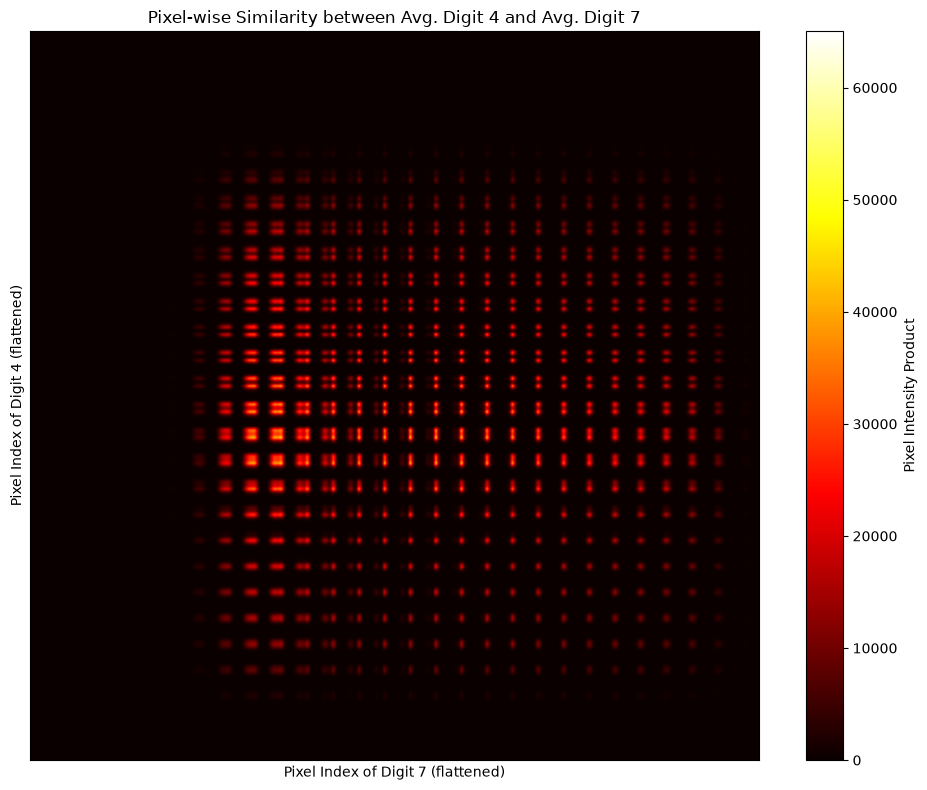

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 加载 MNIST 数据集
file_path = 'mnist.npz' 
with np.load(file_path) as data:
    train_images = data['x_train']
    train_labels = data['y_train']

# 2. 筛选出所有标签为 4 的图像
four_indices = np.where(train_labels == 4)[0]
four_images = train_images[four_indices]

# 3. 筛选出所有标签为 7 的图像
seven_indices = np.where(train_labels == 7)[0]
seven_images = train_images[seven_indices]

# 4. 计算平均图像
four_avg = np.mean(four_images, axis=0) # 形状: (28, 28)
seven_avg = np.mean(seven_images, axis=0) # 形状: (28, 28)
# 在 reshape 之前添加翻转操作
#four_avg_corrected = np.flipud(four_avg).reshape(-1)
#seven_avg_corrected = np.flipud(seven_avg).reshape(-1)

# 然后再计算外积
#similarity_matrix = np.outer(four_avg_corrected, seven_avg_corrected)
# 5. 展平平均图像
flattened_four_avg = four_avg.reshape(-1) # 形状: (784,)
flattened_seven_avg = seven_avg.reshape(-1) # 形状: (784,)

# 6. 构建 784x784 的相似度矩阵
# 这里我们用外积来构建矩阵，矩阵元素[i, j] = four_avg[i] * seven_avg[j]
# 这可以理解为一种加权的共现矩阵
similarity_matrix = np.outer(flattened_four_avg, flattened_seven_avg)


# 7. 绘制热力图
plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix, cmap='hot', vmin=0, vmax=255*255)
plt.colorbar(label='Pixel Intensity Product')
plt.title('Pixel-wise Similarity between Avg. Digit 4 and Avg. Digit 7')
plt.xlabel('Pixel Index of Digit 7 (flattened)')
plt.ylabel('Pixel Index of Digit 4 (flattened)')
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

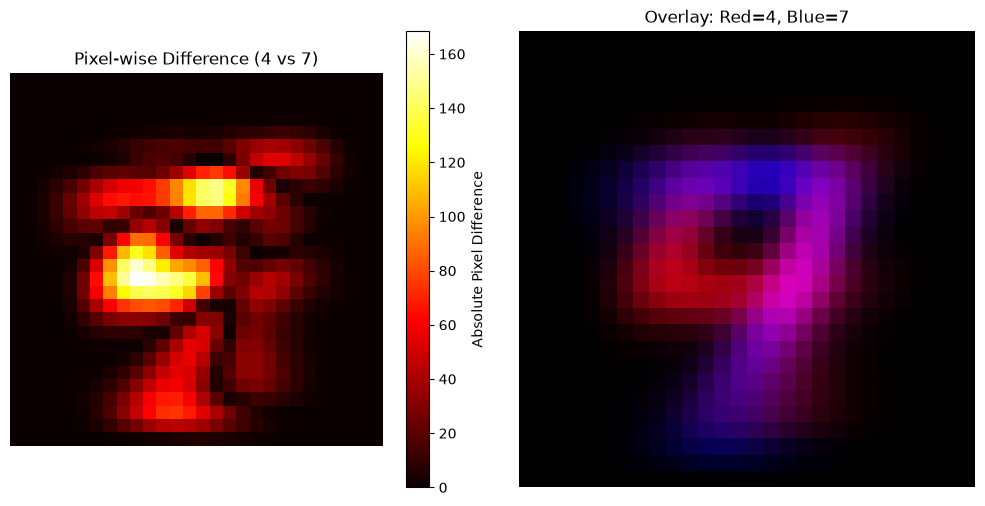

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 加载 MNIST 数据集
file_path = 'mnist.npz'
with np.load(file_path) as data:
    train_images = data['x_train']
    train_labels = data['y_train']

# 2. 筛选并计算平均图像 (保持 28x28 形状)
four_avg = np.mean(train_images[train_labels == 4], axis=0)
seven_avg = np.mean(train_images[train_labels == 7], axis=0)

# 3. 计算差异矩阵 (绝对差值)
# 如果某点很亮，说明该位置一个数字有笔画，另一个没有（或者强度差异很大）
diff_matrix = np.abs(four_avg - seven_avg)

# 4. 绘图
plt.figure(figsize=(10, 5))

# 子图1：显示差异热力图
plt.subplot(1, 2, 1)
plt.imshow(diff_matrix, cmap='hot')
plt.colorbar(label='Absolute Pixel Difference')
plt.title('Pixel-wise Difference (4 vs 7)')
plt.axis('off')

# 子图2：叠加显示（辅助理解）
plt.subplot(1, 2, 2)
# 红色代表4独有，蓝色代表7独有，白色代表共有
overlay = np.zeros((*four_avg.shape, 3))
overlay[..., 0] = four_avg / 255.0  # Red channel for 4
overlay[..., 2] = seven_avg / 255.0 # Blue channel for 7
plt.imshow(overlay)
plt.title('Overlay: Red=4, Blue=7')
plt.axis('off')

plt.tight_layout()
plt.show()

正在计算 784×784 相关系数矩阵，请稍候...


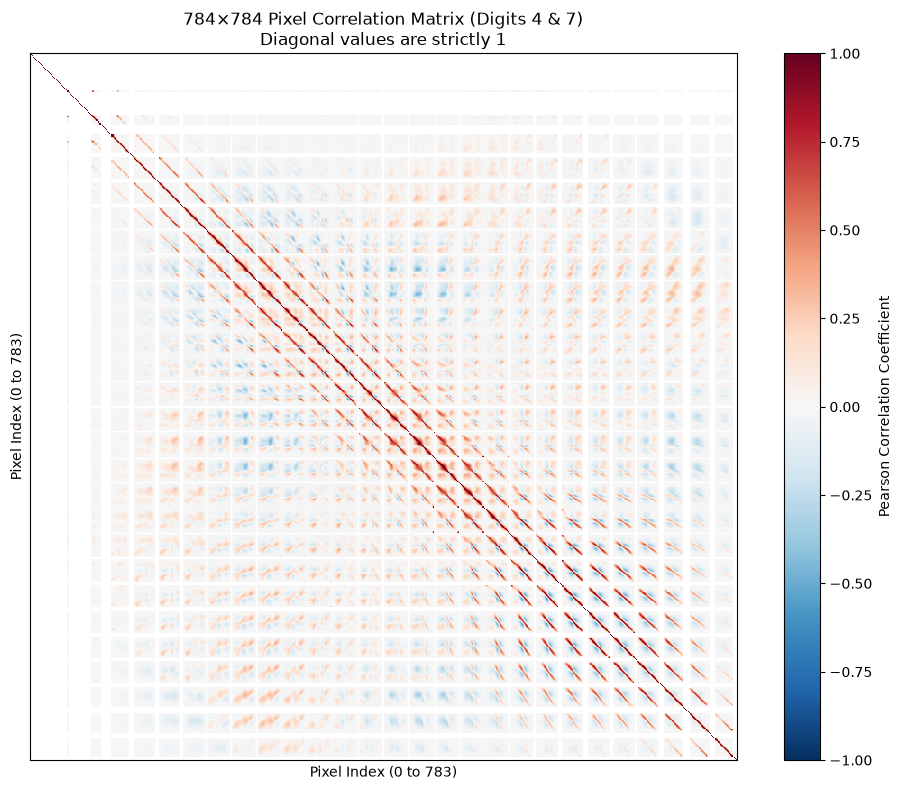

矩阵形状: (784, 784)
对角线最小值: 1.0
对角线最大值: 1.0


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 加载 MNIST 数据集
file_path = 'mnist.npz' 
with np.load(file_path) as data:
    train_images = data['x_train']
    train_labels = data['y_train']

# 2. 筛选出所有标签为 4 和 7 的原始图像（注意：这里不使用平均图像）
# 将图像展平为 (样本数, 784) 的二维矩阵
images_4 = train_images[train_labels == 4].reshape(-1, 784).astype(np.float32)
images_7 = train_images[train_labels == 7].reshape(-1, 784).astype(np.float32)

# 3. 将数字 4 和数字 7 的所有样本合并
# combined_data 的形状为 (N_total_samples, 784)
# 每一列代表一个“像素变量”（共784个），每一行代表一张“手写样本”
combined_data = np.vstack([images_4, images_7])

# 4. 构建 784×784 的皮尔逊相关系数矩阵
# rowvar=False 表示每一列是一个变量（像素），每一行是一个观测值（样本）
# 数学原理：任何变量与自身的相关系数恒为 1，因此对角线天然全为 1
print("正在计算 784×784 相关系数矩阵，请稍候...")
correlation_matrix = np.corrcoef(combined_data, rowvar=False)

# 消除极微小的浮点数计算误差，强制对角线绝对为 1.0
np.fill_diagonal(correlation_matrix, 1.0)

# 5. 绘制热力图
plt.figure(figsize=(10, 8))

# 使用 'RdBu_r' 配色：红色表示正相关，蓝色表示负相关，白色表示不相关
plt.imshow(correlation_matrix, cmap='RdBu_r', vmin=-1, vmax=1, interpolation='nearest')

plt.colorbar(label='Pearson Correlation Coefficient')
plt.title('784×784 Pixel Correlation Matrix (Digits 4 & 7)\nDiagonal values are strictly 1')
plt.xlabel('Pixel Index (0 to 783)')
plt.ylabel('Pixel Index (0 to 783)')

# 隐藏密集的刻度
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()

# 验证矩阵属性
print(f"矩阵形状: {correlation_matrix.shape}")
print(f"对角线最小值: {np.min(np.diag(correlation_matrix))}")
print(f"对角线最大值: {np.max(np.diag(correlation_matrix))}")